Column Space basis vectors:


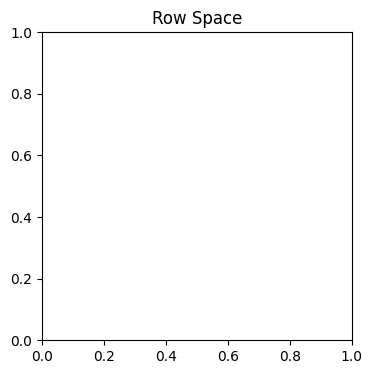

Row Space basis vectors:


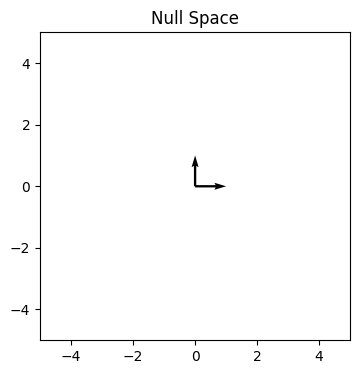

Null Space basis vectors:
Matrix([[1], [0]])
Matrix([[0], [1]])


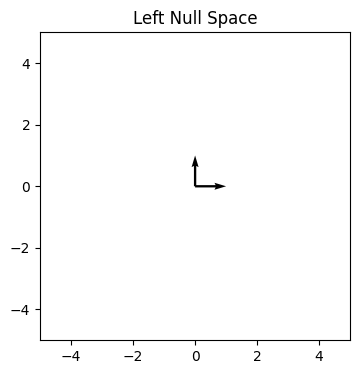

Left Null Space basis vectors:
Matrix([[1], [0]])
Matrix([[0], [1]])


In [3]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from IPython.display import display, clear_output

def visualize_subspaces(A):
    M = sp.Matrix(A)
    col_space = M.columnspace()
    row_space = M.rowspace()
    null_space = M.nullspace()
    left_null_space = M.T.nullspace()

    spaces = {
        "Column Space": col_space,
        "Row Space": row_space,
        "Null Space": null_space,
        "Left Null Space": left_null_space
    }

    dim = A.shape[0]
    for name, basis in spaces.items():
        fig = plt.figure(figsize=(4,4))
        ax = fig.add_subplot(111, projection='3d' if dim == 3 else None)
        ax.set_title(name)

        # plot basis vectors
        for v in basis:
            vec = np.array(v, dtype=float).flatten()
            if dim == 2:
                ax.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1)
                ax.set_xlim(-5,5)
                ax.set_ylim(-5,5)
            else:
                ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], length=1)
                ax.set_xlim(-5,5)
                ax.set_ylim(-5,5)
                ax.set_zlim(-5,5)
        plt.show()
        print(f"{name} basis vectors:")
        for v in basis:
            print(v)

def on_matrix_change(*args):
    clear_output(wait=True)
    # read matrix entries
    vals = [w.value for w in matrix_inputs]
    A = np.array(vals).reshape((n_dim.value, n_dim.value))
    visualize_subspaces(A)

# dimension selector
n_dim = widgets.Dropdown(options=[2,3], value=2, description='Size n×n:')
matrix_inputs = []

def create_matrix_inputs(change):
    global matrix_inputs
    for w in matrix_inputs:
        w.close()
    matrix_inputs = []
    inputs_grid = widgets.GridBox([], layout=widgets.Layout(grid_template_columns=(" ".join(["100px"]*n_dim.value))))
    for i in range(n_dim.value**2):
        w = widgets.FloatText(value=0, description=f"a{i//n_dim.value+1}{i%n_dim.value+1}:")
        w.observe(on_matrix_change, names='value')
        matrix_inputs.append(w)
        inputs_grid.children += (w,)
    display(inputs_grid)
    on_matrix_change()

n_dim.observe(lambda change: create_matrix_inputs(change), names='value')

display(n_dim)
create_matrix_inputs(None)